### Imports

Load libraries used for data manipulation and analysis (`pandas`).

In [1]:
import pandas as pd

### Load dataset

Read the Iris CSV into a DataFrame `df`. Ensure the file is in the working directory.

In [2]:
df = pd.read_csv('IRIS.csv')

### Quick typo check

This cell currently contains a stray or mistyped expression; remove or correct it if unintended.

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### Inspect data (head)

Show the first rows to verify columns and sample values.

In [4]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


### Dataframe info

Display column types and non-null counts to check for missing values and types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Target distribution

Count unique labels in the `species` column to inspect class balance.

In [6]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Visualization libraries

Import plotting libraries used for visual EDA (`seaborn`, `matplotlib`).

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

KeyboardInterrupt: 

### Species count barplot

Create a bar plot of species counts and label bars for readability.

[Text(0, 0, '50'), Text(0, 0, '50'), Text(0, 0, '50')]

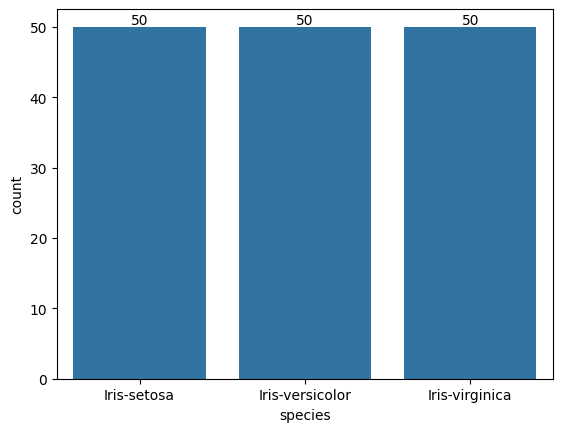

In [ ]:
bar = sns.barplot(df['species'].value_counts())
bar.bar_label(bar.containers[0], fontsize=10)

### Encoding target

Import `LabelEncoder` to convert categorical `species` labels into numeric `outcome`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

### Apply encoding

Fit the encoder and add a numeric `outcome` column to `df` for modeling.

In [ ]:
encoder = LabelEncoder()
df['outcome'] = encoder.fit_transform(df['species'])

### Show full DataFrame

Display `df` to confirm the new `outcome` column and overall structure.

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,outcome
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,2
146,6.3,2.5,5.0,1.9,Iris-virginica,2
147,6.5,3.0,5.2,2.0,Iris-virginica,2
148,6.2,3.4,5.4,2.3,Iris-virginica,2


### Random sample

Show a small random sample of rows to inspect variability across examples.

In [ ]:
df.sample(12)

,sepal_length,sepal_width,petal_length,petal_width,species,outcome
76,6.8,2.8,4.8,1.4,Iris-versicolor,1
131,7.9,3.8,6.4,2.0,Iris-virginica,2
129,7.2,3.0,5.8,1.6,Iris-virginica,2
0,5.1,3.5,1.4,0.2,Iris-setosa,0
59,5.2,2.7,3.9,1.4,Iris-versicolor,1
44,5.1,3.8,1.9,0.4,Iris-setosa,0
122,7.7,2.8,6.7,2.0,Iris-virginica,2
21,5.1,3.7,1.5,0.4,Iris-setosa,0
46,5.1,3.8,1.6,0.2,Iris-setosa,0
95,5.7,3.0,4.2,1.2,Iris-versicolor,1


### Prepare features and target

Separate the target `y` from features `X` by dropping label columns.

In [ ]:
y = df['outcome']
X = df.drop(columns=['species', 'outcome'])

### Feature names

List the columns in `X` to confirm which numeric features will be analyzed.

In [ ]:
colums = X.columns
colums

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

### Feature distributions

Plot histograms/density plots for each numeric feature to inspect distributions and outliers.

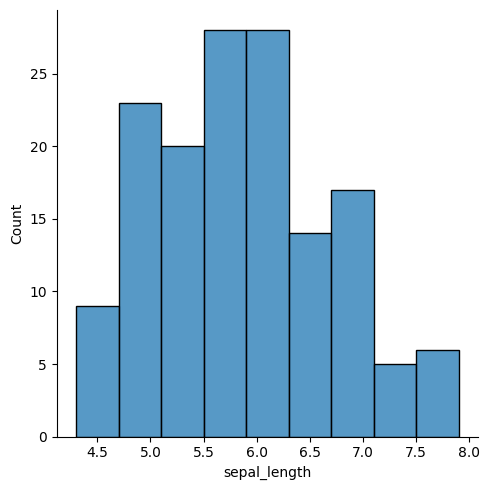

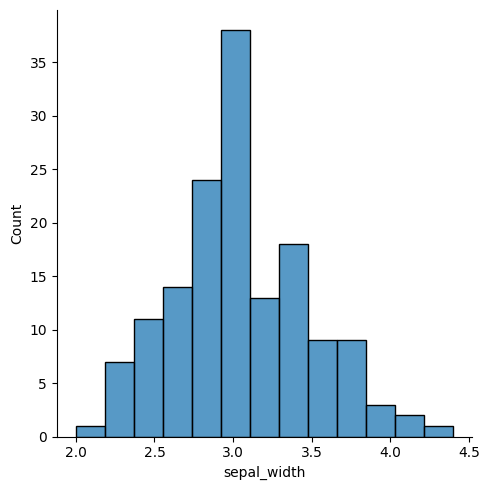

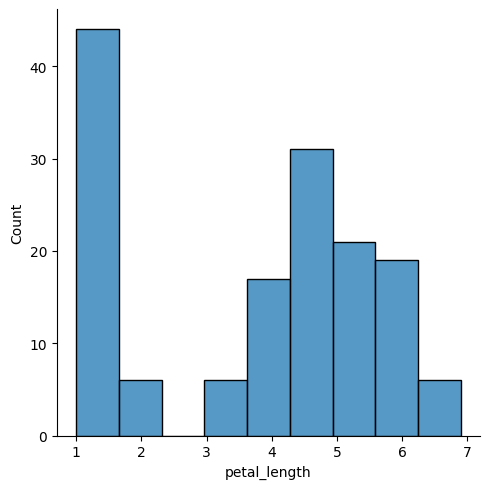

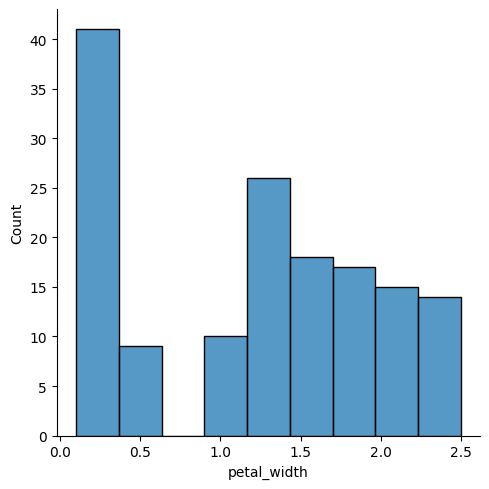

In [ ]:
for col in colums:
   sns.displot(df[col])

### Correlation computation

Compute the Pearson correlation matrix for features in `X` to identify correlated pairs.

In [ ]:
X.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


### Correlation matrix

This cell displays the Pearson correlation matrix for the numeric features in `X` (sepal/petal measurements).
Values near 1 or -1 indicate strong positive/negative correlation; values near 0 indicate weak correlation.
Use this to detect multicollinearity before modeling.

### Notes / Next steps

Consider adding a heatmap visualization of the correlation matrix and handling multicollinearity if present.

<Axes: >

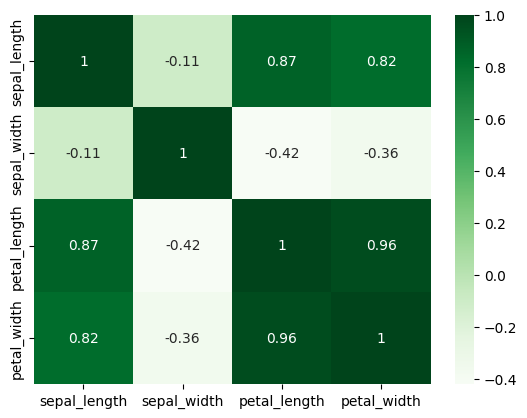

In [ ]:
sns.heatmap(X.corr(), annot=True, cmap = 'Greens')

this is the heatmap to discribe correlation in agraphic way

In [ ]:
from sklearn.model_selection import train_test_split

### Train-test split

Import and apply train-test split to divide data into 80% training and 20% testing sets with a fixed random state for reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression setup

Import and train a logistic regression classifier on the training data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### Model evaluation metrics

Import tools for classification reporting and confusion matrix analysis.

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Train logistic regression

Instantiate and fit the logistic regression model to the training set.

In [ ]:
print("Accuracy train = ", model.score(X_train, y_train))
print("Accuracy test = ", model.score(X_test, y_test))

Accuracy train =  0.975
Accuracy test =  1.0


### Model accuracy scores

Calculate and display accuracy on both training and test sets to assess overfitting/underfitting.

In [ ]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

### Generate predictions

Predict class labels for both training and test sets.

In [ ]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.93      0.96        41
           2       0.93      1.00      0.96        39

    accuracy                           0.97       120
   macro avg       0.98      0.98      0.97       120
weighted avg       0.98      0.97      0.97       120



### Classification report

Display precision, recall, and F1-score for each class on the training set.

In [ ]:
from sklearn.metrics import confusion_matrix

### Confusion matrix tools

Import the confusion matrix function for detailed error analysis.

In [ ]:
cm = confusion_matrix(y_train, pred_train)

### Compute confusion matrix

Calculate the confusion matrix for training predictions to visualize classification errors.

<Axes: >

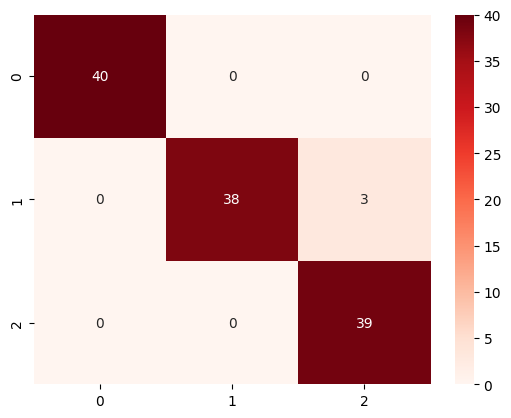

In [ ]:
sns.heatmap(cm, annot=True, cmap='Reds')

### Confusion matrix heatmap

Visualize the confusion matrix using a heatmap to see correct and incorrect predictions by class.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

### K-Nearest Neighbors setup

Import the KNN classifier for comparison with logistic regression.

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(X_train, y_train)
print("Accuracy train KNN = ", model_knn.score(X_train, y_train))
print("Accuracy test KNN = ", model_knn.score(X_test, y_test))

Accuracy train KNN =  0.975
Accuracy test KNN =  0.9666666666666667


### Train KNN model

Fit a KNN classifier with k=7 neighbors and display accuracy on training and test sets.

In [ ]:
from sklearn.svm import SVC

### Support Vector Machine setup

Import the SVM classifier for multi-class classification.

In [ ]:
model_svc = SVC(kernel='linear')
model_svc.fit(X_train, y_train)
print("Accuracy train SVC = ", model_svc.score(X_train, y_train))
print("Accuracy test SVC = ", model_svc.score(X_test, y_test))

Accuracy train SVC =  0.975
Accuracy test SVC =  1.0


### Train SVM model

Fit an SVM classifier with linear kernel and display accuracy on training and test sets.